In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import torch
import wandb
from tqdm import tqdm

from src.distributions import StandardNormalSampler, SwissRollSampler
from src.light_gcot import LightGCOT

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
torch.set_default_tensor_type(torch.DoubleTensor)

/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/torch/__init__.py:749: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969118/work/torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


## 2. Config

In [32]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 500
M_POTENTIALS = 25
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 1.0

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.002

D_LR = 3e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float("inf")

PLOT_EVERY = 500
MAX_STEPS = 20000
CONTINUE = -1

In [33]:
torch.manual_seed(OUTPUT_SEED)

In [47]:
OUTPUT_PATH

'../checkpoints/LightGCOT_Swiss_Roll_EPSILON_0.002_MAX_STEPS_20000_N_500_M_25_with_MLP_cost_included_True_c(x,y)=||x+y||^2_rand'

In [34]:
EXP_COST = "MLP"
EXP_COST_INCLUDED = True
EXP_META_INFO = "_c(x,y)=||x+y||^2"
EXP_NAME = (
    f"LightGCOT_Swiss_Roll_EPSILON_{EPSILON}_MAX_STEPS_{MAX_STEPS}_N_{N_POTENTIALS}_M_{M_POTENTIALS}_with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [35]:
X_sampler = StandardNormalSampler(dim=X_DIM, device=device)
Y_sampler = SwissRollSampler(dim=Y_DIM, device=device)

## 4. Model initialization

In [36]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

## 5. Model training

In [37]:
from src.discrete_ot import OTPlanSampler
from src.plotting import plot_A_parameters, plot_B_parameters, plot_distributions

In [38]:
otp_sampler = OTPlanSampler("sinkhorn")

In [39]:
starting_points = torch.tensor([[-1.5, 1.5], [0.0, 0.0], [1.5, -1.5]])

In [40]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt.zero_grad()

    if EXP_COST_INCLUDED:
        _X, _Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)
        X, Y = otp_sampler.sample_plan(_X, _Y)
    else:
        X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    log_v_m = D.compute_log_v_m(X)  # [bs x M]
    b_m = D.compute_b_m(X)  # [bs x M x y_dim]

    log_w_n = D.compute_log_w_n() # [N]
    a_n = D.compute_a_n() # [N x y_dim]
    A_n = D.compute_A_n() # [N x y_dim]

    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
    f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)

    if EXP_COST_INCLUDED:
        c = D.compute_cost(Y, log_v_m, b_m)
        D_loss = (c - f_c - f).mean()
        D_loss.backward()
        wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
    else:
        D_loss = -(f_c + f).mean()
        D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)
    wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
    wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
    wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
    wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)

    if step % PLOT_EVERY == 0:
        A_dict = plot_A_parameters(D, log=True)
        B_dict = plot_B_parameters(D, starting_points, log=True)
        distr_dict = plot_distributions(D, X_sampler, Y_sampler, starting_points, log=True)
        wandb.log(A_dict | B_dict | distr_dict)

        torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))
        torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{step}.pt"))

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{MAX_STEPS}.pt"))

wandb.finish()

  0%|                                                                                                                                                                                 | 0/20000 [00:00<?, ?it/s]/beegfs/home/m.persiyanov/Light-GCOT/src/plotting.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="lower right")
  0%|                                                                                                                                                                        | 13/20000 [00:02<32:33, 10.23it/s]/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "
1

$-f(y)$,▄▃▂▂▂▂▃▆█▅▄▂▂▂▂▂▂▁▂▂▂▁▂▁▂▁▁▁▂▁▂▂▁▁▁▂▂▁▁▂
$-f(y)-f^c(x)$,█▇▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
$-f^c(x)$,█▇▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
"$c(x, y)$",▁▂▃▄▅▅▆▇▇███████████████████████████████
D gradient norm,█▆▄▄▃▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss,█▆▅▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lam_max(A_n),▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▇▇▇███
lam_min(A_n),█▇▅▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂
$-f(y)$,0.00373
$-f(y)-f^c(x)$,0.00801
$-f^c(x)$,0.00428


## Plotting

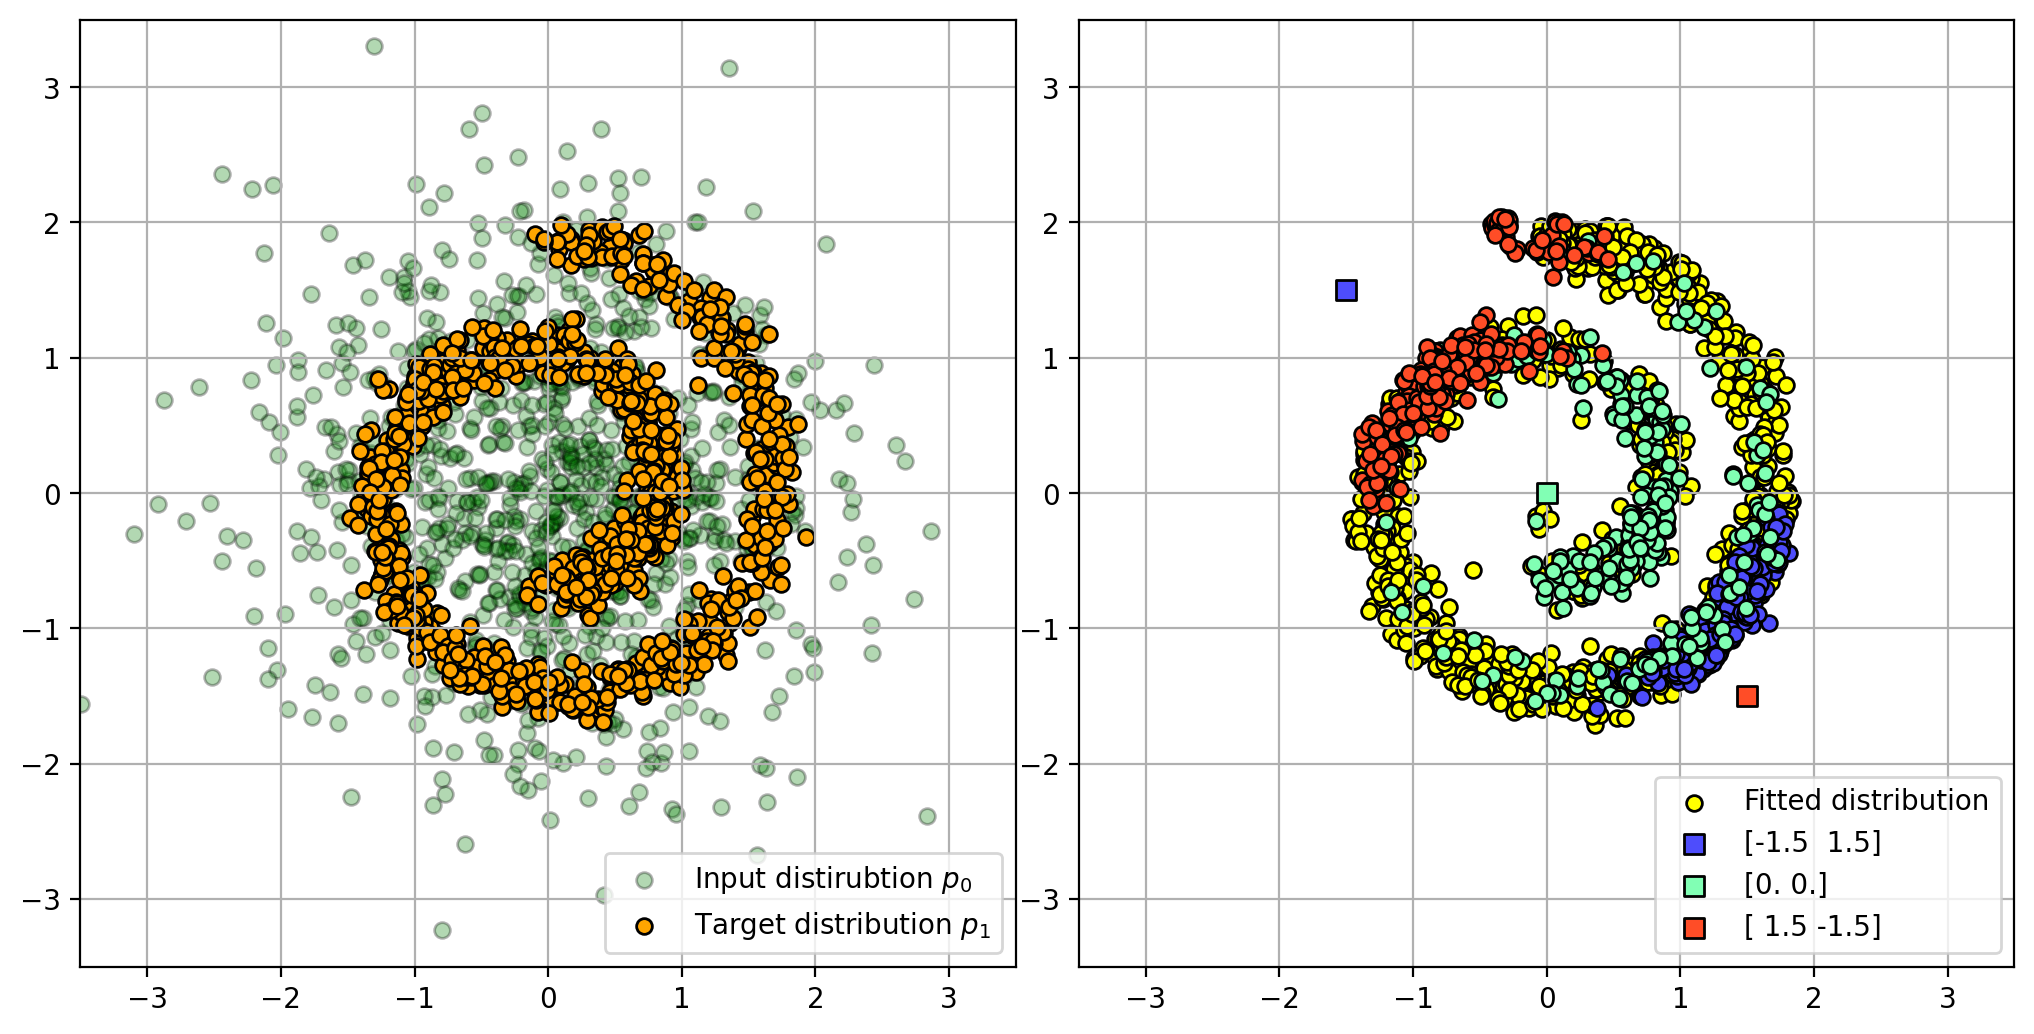

In [41]:
plot_distributions(D, X_sampler, Y_sampler, starting_points)